In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Debug
import ipdb
deb = ipdb.set_trace

# General imports
import os
import re
import sys
import cortex
import datetime
import numpy as np
import pandas as pd

# MRI analysis imports
import nibabel as nb
from prfpy_csenf.fit import CSenFFitter
# from prfpy_csenf.model import CSenFModel
# from prfpy_csenf.stimulus import CSenFStimulus
# from prfpy_csenf.rf import * 
from prfpy_csenf.stimulus_gaussian import CSenFGaussianStimulus, CSenFGaussianModel
from prfpy_csenf.csenf_plot_functions import *

# Personal imports
sys.path.append("{}/../../../../analysis_code/utils".format(os.getcwd()))
from settings_utils import load_settings
from cifti_utils import from_170k_to_59k
from pycortex_utils import set_pycortex_config_file, get_rois, draw_cortex
from surface_utils import load_surface, make_surface_image

In [2]:
# Get inputs cd ~/projects/pRF_analysis/nCSF/postproc/nCSF/fit
start_time = datetime.datetime.now()

# Inputs
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'nCSF'
subject = 'sub-01'
sub_num = subject[4:]
input_fn = '{}/{}/derivatives/pp_data/sub-01/170k/func/fmriprep_dct_z-score_avg/sub-01_task-nCSF_fmriprep_dct_z-score_avg_bold.dtseries.nii'.format(main_dir, project_dir)
n_jobs = 8

n_batches = n_jobs
verbose = False

In [3]:
# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)

In [4]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
settings = load_settings([settings_path, prf_settings_path])
analysis_info = settings[0]

TR = analysis_info['TR']
TRs = analysis_info['TRs']
pycortex_subject_template = analysis_info['pycortex_subject_template']

In [5]:
nCSF_ses = 'ses-01'
nCSF_task_name = 'nCSF'
rois_method_format = 'rois-group-mmp'
if rois_method_format == 'rois-drawn':
    rois = analysis_info[rois_method_format]
    # rois = ['V1', 'V2', 'V3']
elif rois_method_format == 'rois-group-mmp':
    # rois = list(analysis_info[rois_method_format].keys())
    rois = ['V1', 'V2', 'V3']
    # rois = ['V1', 'V2']

In [6]:
ncsf_grid_nr = 4
rsq_threshold = 0.1 
ncsf_params_num = 10

ncsf_maps_names = ['width_r', 'SFp', 'CSp', 'width_l', 'crf_exp', 'amp_1', 
                   'bold_baseline', 'hrf_1', 'hrf_2', 'r_squared']



sf_minFreq = 0.05
sf_maxFreq = 16
sf_filtNum = 6 

minCont = 0.25
maxCont = 80
contNum = 12

sf_sigma = 0.3534

sf_filtCenters = np.concatenate([np.round(np.logspace(np.log10(0.05), np.log10(16), sf_filtNum), 2), [0]])
contValues = np.concatenate([np.logspace(np.log10(minCont), np.log10(maxCont), contNum), [0]])

In [7]:
if input_fn.endswith('.nii'):
   format_ = '170k'
   pycortex_subject =  pycortex_subject_template
   hemi = None

    
elif input_fn.endswith('.gii'):
   format_ = 'fsnative'
   pycortex_subject =  subject
   match = re.search(r'hemi-[LR]', input_fn)
   hemi = match.group()

In [8]:
# Create Stimulus object
# Load events to have stim sequence
events_dir = '{}/{}/{}/{}/func'.format(main_dir, project_dir, subject, nCSF_ses)
events_fn = '{}/{}_{}_task-{}_dir-PA_run-01_events.tsv'.format(events_dir, subject, nCSF_ses, nCSF_task_name)
events_df = pd.read_table(events_fn, sep="\t")

# Create mapping betwen SF, MC numbers and real values
mapping_SF = {i+1: sf_filtCenters[i] for i in range(len(sf_filtCenters))}
mapping_MC = {i+1: contValues[i] for i in range(len(contValues))}

events_df['spatial_frequency'] = events_df['spatial_frequency'].replace(mapping_SF)
events_df['michelson_contrast'] = events_df['michelson_contrast'].replace(mapping_MC)

sfs_seq = np.array(events_df['spatial_frequency'])
con_seq = np.array(events_df['michelson_contrast'])

# Après
csenf_stim = CSenFGaussianStimulus(
    SF_seq=sfs_seq, CON_seq=con_seq, TR=TR,
    sf_sigma   = sf_sigma,          
    n_SF_bins  = 50,
    n_CON_bins = 50,
    SF_range   = (sf_minFreq, sf_maxFreq),
    CON_range  = (minCont, maxCont),
)

[CSenFGaussianStimulus] Number of timepoints: 214
[CSenFGaussianStimulus] Design matrix shape: (50, 50, 214)  (n_CON=50, n_SF=50, n_TRs=214)
[CSenFGaussianStimulus] sf_sigma (log10-SF) = 0.3534


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# matrice 3D (X, Y, T)
data = csenf_stim.design_matrix

# temps entre chaque frame (s)
TR = 1.6

# nombre de frames
t = data.shape[2]

# fps de la vidéo
fps = 1 / TR

# création de la figure
fig, ax = plt.subplots()

im = ax.imshow(
    data[:, :, 0],
    cmap="viridis",
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="lower"
)
ax.set_xlabel("Spatial frequency")
ax.set_ylabel("Contrast")
ax.set_xticks([])  # enlève les ticks en x
ax.set_yticks([]) 
# ax.set_axis_off()

# writer vidéo
writer = FFMpegWriter(fps=fps)

output_path = "/Users/uriel/Downloads/design_matrix_video.mp4"

with writer.saving(fig, output_path, dpi=200):
    for i in range(t):
        im.set_data(data[:, :, i])
        writer.grab_frame()

plt.close(fig)

print(f"Video saved to {output_path}")

Video saved to /Users/uriel/Downloads/design_matrix_video.mp4


Text(0.5, 0, 'Spatial frequency')

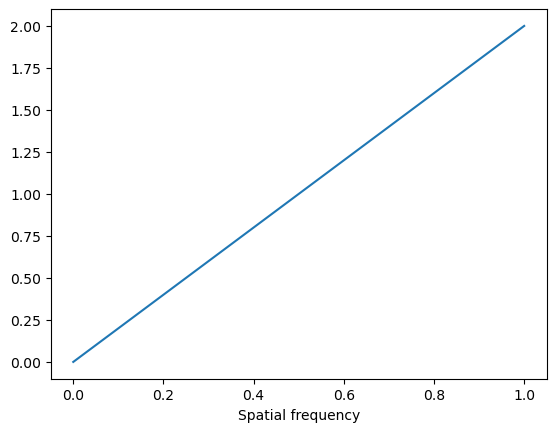

In [35]:
fig, ax = plt.subplots()
ax.plot([0,2])
ax.set_xlabel("Spatial frequency")

In [10]:
# load data
img, raw_data = load_surface(fn=input_fn)
len_data = raw_data.shape[1]

# Extract data from rois 
roi_verts_dict = get_rois(pycortex_subject, 
                          surf_format=format_, 
                          rois_type=rois_method_format,
                          mask=True, 
                          rois=rois, 
                          hemis=hemi)

masks = np.stack(list(roi_verts_dict.values()), axis=0)  
rois_mask = masks.any(axis=0)
na_vertices = np.isnan(raw_data).any(axis=0)
rois_mask = np.logical_and(rois_mask, ~na_vertices)
roi_idx = np.where(rois_mask)[0]
data = raw_data[:, rois_mask]

In [11]:
# Dermine nCSF model
csenf_model = CSenFGaussianModel(stimulus=csenf_stim, 
                                 hrf=[1,1,0], 
                                 edge_type='CRF')

csenf_fitter = CSenFFitter(data=data.T, 
                           model=csenf_model, 
                           n_jobs=n_jobs)

In [12]:
# nCSF bounds
ncsf_bounds = {
    'width_r' : [0,1.5],          
    'SFp' : [0, 10],
    'CSp' : [0, 200] ,
    'width_l' : [0.68, 0.68],
    'crf_exp' : [0, 10],
    'amp_1' : [0, 6],
    'bold_baseline' : [-1,1] ,
    'hrf_1' : [1, 1],
    'hrf_2' : [0,0],
}


width_r_grid = np.linspace(ncsf_bounds['width_r'][0], ncsf_bounds['width_r'][1], ncsf_grid_nr)     
SFp_grid = np.linspace(ncsf_bounds['SFp'][0], ncsf_bounds['SFp'][1], ncsf_grid_nr)     
CSp_grid = np.linspace(ncsf_bounds['CSp'][0], ncsf_bounds['CSp'][1], ncsf_grid_nr)
width_l_grid = np.linspace(ncsf_bounds['width_l'][0], ncsf_bounds['width_l'][1], ncsf_grid_nr)     
crf_exp_grid = np.linspace(ncsf_bounds['crf_exp'][0], ncsf_bounds['crf_exp'][1], ncsf_grid_nr)
# hrf_1_grid = None
# hrf_2_grid = None
hrf_1_grid = np.zeros(len(width_r_grid))
hrf_2_grid = np.zeros(len(width_r_grid))

grid_bounds = [ncsf_bounds['amp_1']]
fixed_grid_baseline=False


bounds_list = [
    (ncsf_bounds['width_r']),     # width_r
    (ncsf_bounds['SFp']),     # SFp
    (ncsf_bounds['CSp']),    # CSp
    (ncsf_bounds['width_l']),     # width_l
    (ncsf_bounds['crf_exp']),     # crf_exp
    (ncsf_bounds['amp_1']),   # amp_1
    (ncsf_bounds['bold_baseline']),      # baseline
    (ncsf_bounds['hrf_1']),      # baseline
    (ncsf_bounds['hrf_2']),      # baseline
]

In [13]:
# Grid fit
csenf_fitter.grid_fit(width_r_grid=width_r_grid, 
                      SFp_grid=SFp_grid, 
                      CSp_grid=CSp_grid, 
                      width_l_grid=width_l_grid, 
                      crf_exp_grid=crf_exp_grid, 
                      hrf_1_grid=hrf_1_grid, 
                      hrf_2_grid=hrf_2_grid, 
                      verbose=False,
                      fixed_grid_baseline=fixed_grid_baseline, 
                      grid_bounds=grid_bounds, 
                      n_batches=n_jobs)

/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: divide by zero encountered in divide
  slopes = (n_timepoints * np.dot(vox_data, predictions.T) - sumd *
/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: divide by zero encountered in divide
  slopes = (n_timepoints * np.dot(vox_data, predictions.T) - sumd *
/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: invalid value encountered in divide
  slopes = (n_timepoints * np.dot(vox_data, predictions.T) - sumd *
/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: divide by zero encountered in divide
  slopes = (n_timepoints * np.dot(vox_data, predictions.T) - sumd *
/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: invalid value encountered in divide
  slopes = (n_timepoints * np.dot(vox_data, predictions.T) - sumd *
/Users/uriel/softwares/prfpy_csenf/prfpy_csenf/fit.py:2101: RuntimeWarning: invalid value encount

In [14]:
# Iterative fit
csenf_fitter.iterative_fit(
    rsq_threshold = rsq_threshold,
    verbose = False,
    bounds = bounds_list,
    # constraints = csf_constraints,
    # xtol=xtol,   
    # ftol=ftol,           
    )


ncsf_fit = csenf_fitter.iterative_search_params

# testing

In [16]:
csenf_plot_fit = CSenFPlotter(
    csenf_fitter.iterative_search_params,
    prfpy_model=csenf_model, # Include the model so we can generate predictions
    
    )
csenf_plot_fit.SF_list = sf_filtCenters

prf_params.shape[-1]=10
hrf=params[:,7,8]
rsq=params[:,9]


In [48]:
csenf_plot_fit.pd_params

,width_r,SFp,CSp,width_l,crf_exp,amp_1,bold_baseline,hrf_1,hrf_2,rsq,log10_SFp,log10_CSp,log10_crf_exp,sfmax,log10_sfmax,raw_aulcsf,aulcsf
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
7644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
7645,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0
7646,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-inf,-inf,-inf,NaN,NaN,0.0,0.0


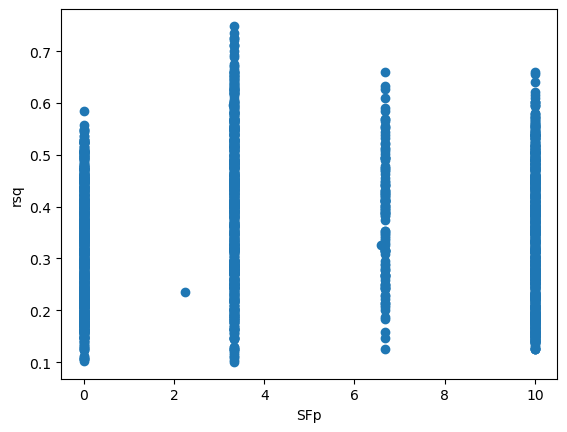

In [45]:
csenf_plot_fit.scatter(px='SFp', py='rsq')

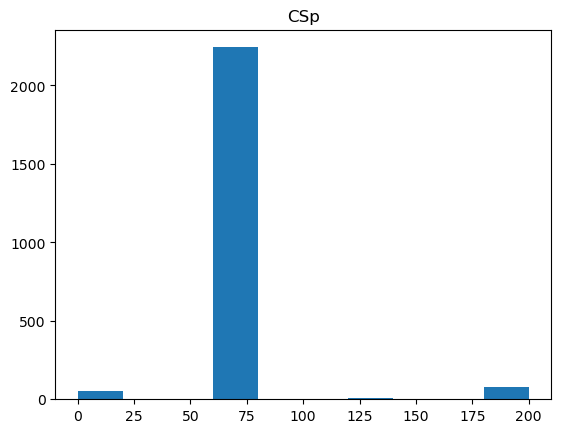

In [47]:
csenf_plot_fit.hist(param='CSp')

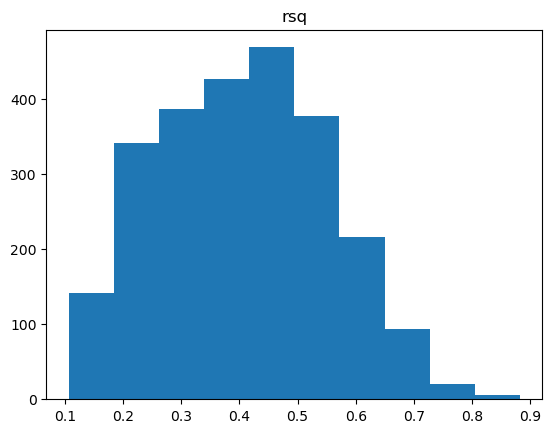

In [16]:
csenf_plot_fit.hist(param='rsq')

In [21]:
# ground_truth_model = 0 # Which ground truth model do we want to look at?

# noisy_fit_ids = csf_model_index==ground_truth_model # which of our noisy fits correspond to this model?
# # Of these which has a good fit! 
fit_to_compare = (csenf_plot_fit.pd_params['rsq']>0.8) #& noisy_fit_ids
fit_to_compare = np.where(fit_to_compare)[0][0]

# Compare the fit (green) vs the dotted line black line (data) 
_ = csenf_plot_fit.csf_ts_plot(fit_to_compare)

# # Now lets look at the original "ground truth" model
# _ = csenf_plot.csf_ts_plot(ground_truth_model)


IndexError: index 0 is out of bounds for axis 0 with size 0

# Saving 

In [19]:
# rearange result of Gauss model 
#gauss_fit = gauss_fitter.gridsearch_params
ncsf_fit_mat = np.zeros((raw_data.shape[1], ncsf_params_num))
ncsf_pred_mat = np.zeros_like(raw_data) 

for est, vert in enumerate(roi_idx):
    ncsf_fit_mat[vert] = ncsf_fit[est]
    ncsf_pred_mat[:,vert] = csenf_model.return_prediction(width_r=ncsf_fit[est][0], 
                                                          SFp=ncsf_fit[est][1], 
                                                          CSp=ncsf_fit[est][2], 
                                                          width_l=ncsf_fit[est][3], 
                                                          crf_exp=ncsf_fit[est][4],
                                                          beta=ncsf_fit[est][5],
                                                          baseline=ncsf_fit[est][6],
                                                          hrf_1=ncsf_fit[est][7],
                                                          hrf_2=ncsf_fit[est][8])

In [22]:
best_r2_idx = np.argmax(ncsf_fit_mat[:,-1])
print('best R2 is {} with idx {}'.format(ncsf_fit_mat[best_r2_idx, -1], best_r2_idx))

best R2 is 0.7487832307815552 with idx 40120


In [23]:
ncsf_fit_mat.shape

(170494, 10)

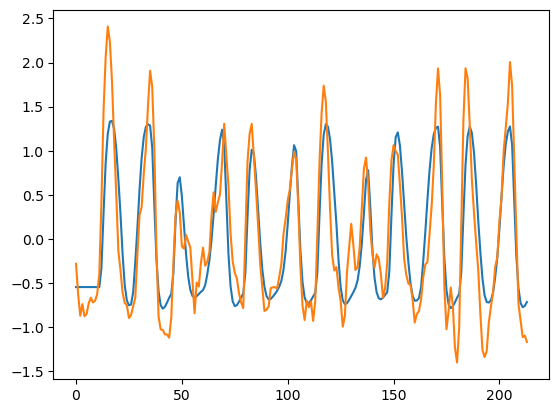

In [24]:
plt.plot(ncsf_pred_mat[:,best_r2_idx])
plt.plot(raw_data[:,best_r2_idx])

In [25]:
pycortex_subject = 'sub-hcp1.6mm'

data_59k =  from_170k_to_59k(img=img, data=ncsf_fit_mat.T, return_concat_hemis=True, return_59k_mask=False)
ncsf_fit59k = data_59k['data_concat']

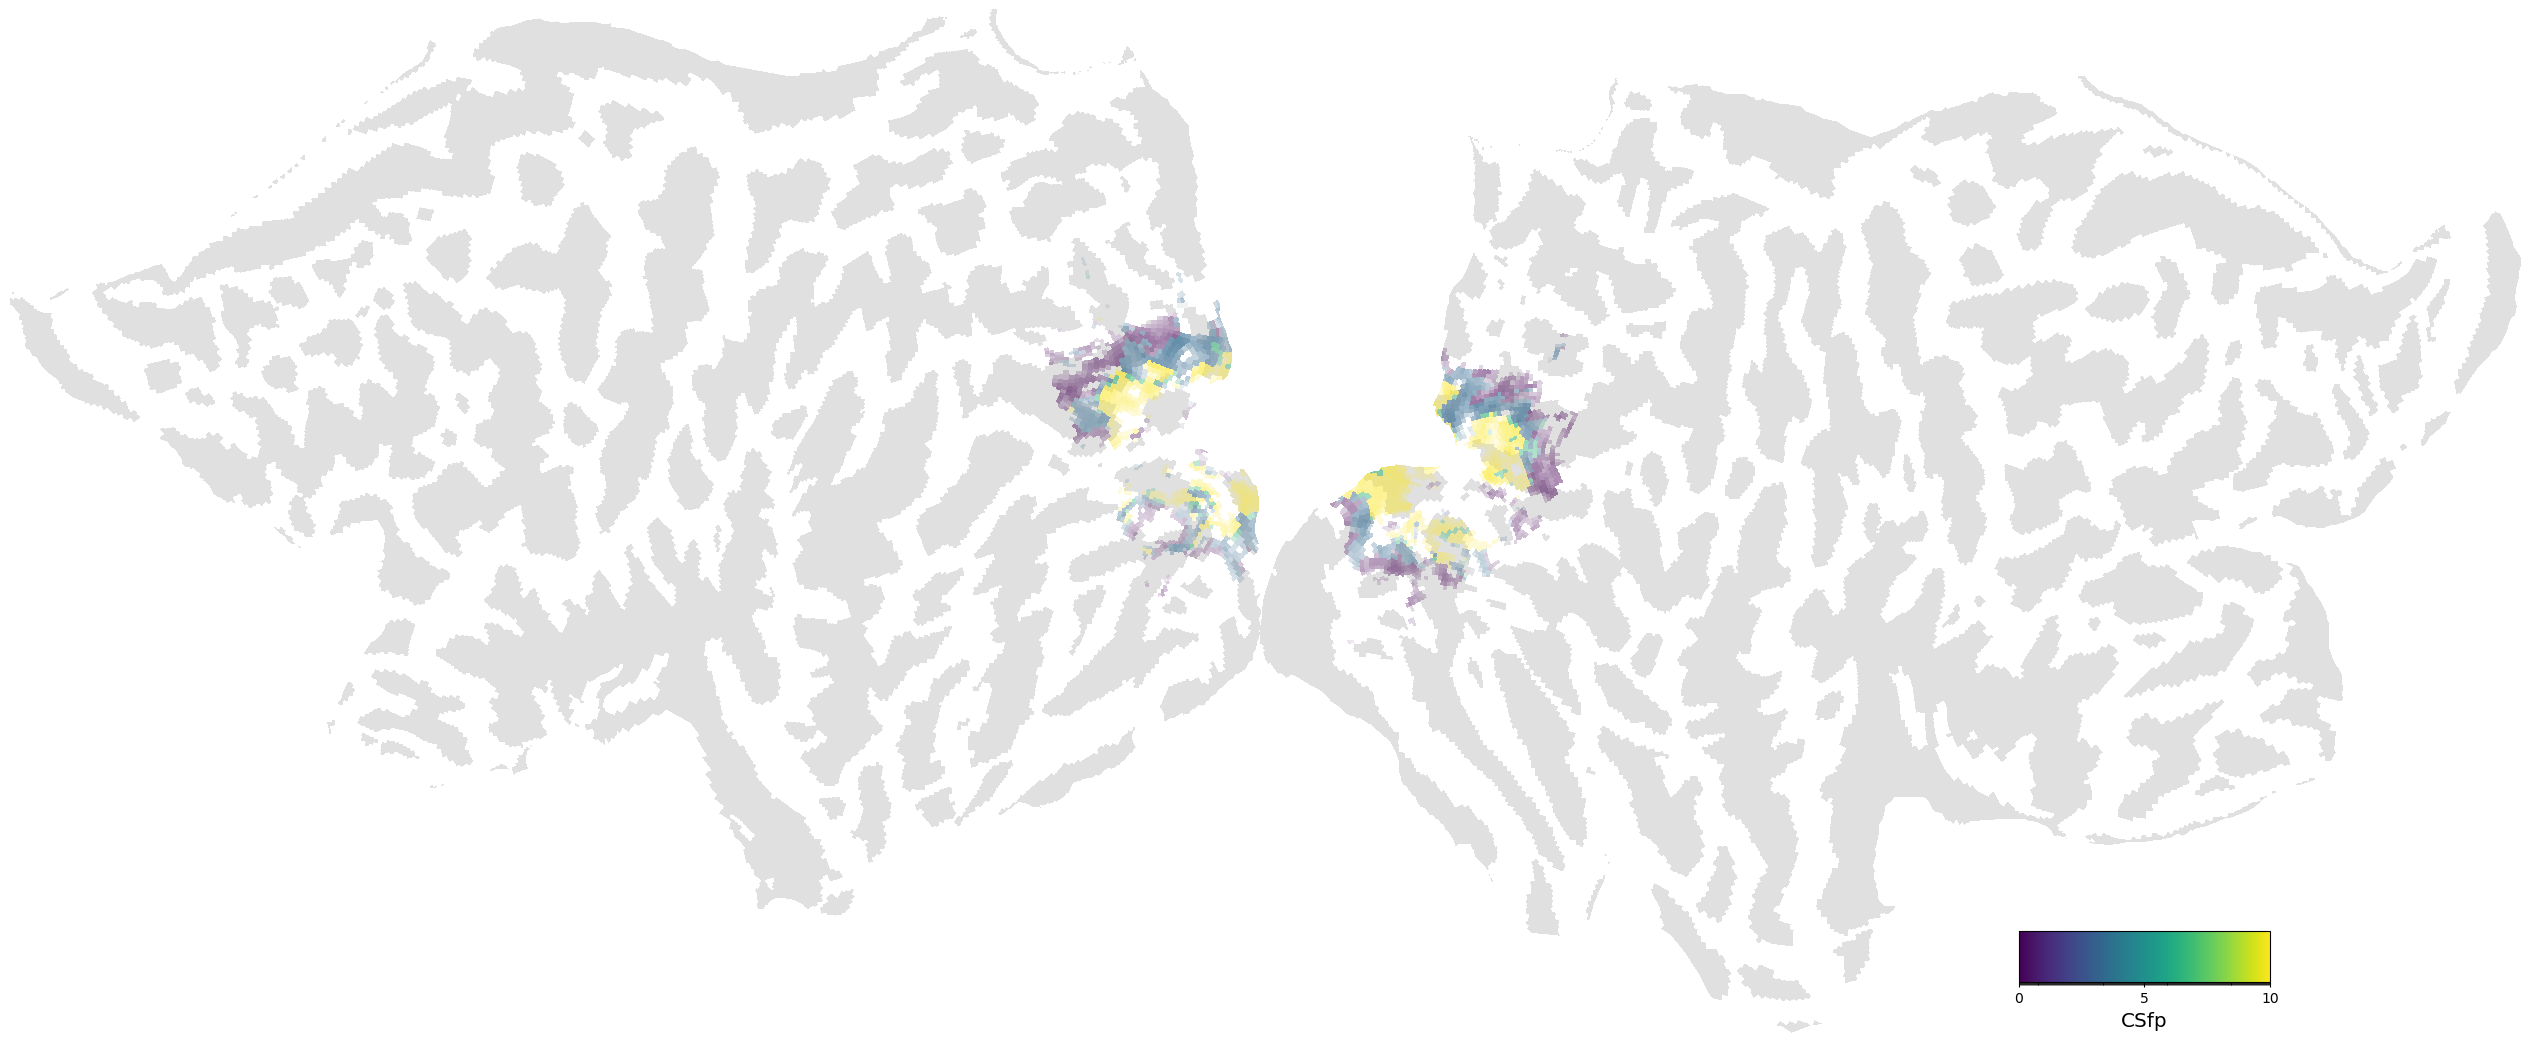

In [26]:
prf_loo_r2_idx = -1
loo_rsq_data = ncsf_fit59k[prf_loo_r2_idx,:]
alpha = loo_rsq_data
alpha_range = [0,1]
alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
alpha[alpha>1]=1

# put alpha to 0 outside non interest roi 

sfp_params = {
             'subject': pycortex_subject,
             'data': ncsf_fit59k[1,:], 
             'cmap': 'viridis', 
             'alpha': alpha, 
             'vmin': 0, 
             'vmax': 10, 
             'cbar': 'discrete', 
             'cortex_type': 'VertexRGB', 
             'description': 'CSS pRF CM',
             'curv_brightness': 1, 
             'curv_contrast': 0.25, 
             'add_roi': False, 
             'cbar_label': 'CSfp',
             'with_labels': True}
volume_sfp = draw_cortex(**sfp_params)
# plt.savefig('/Users/uriel/Downloads/CSFp.pdf')

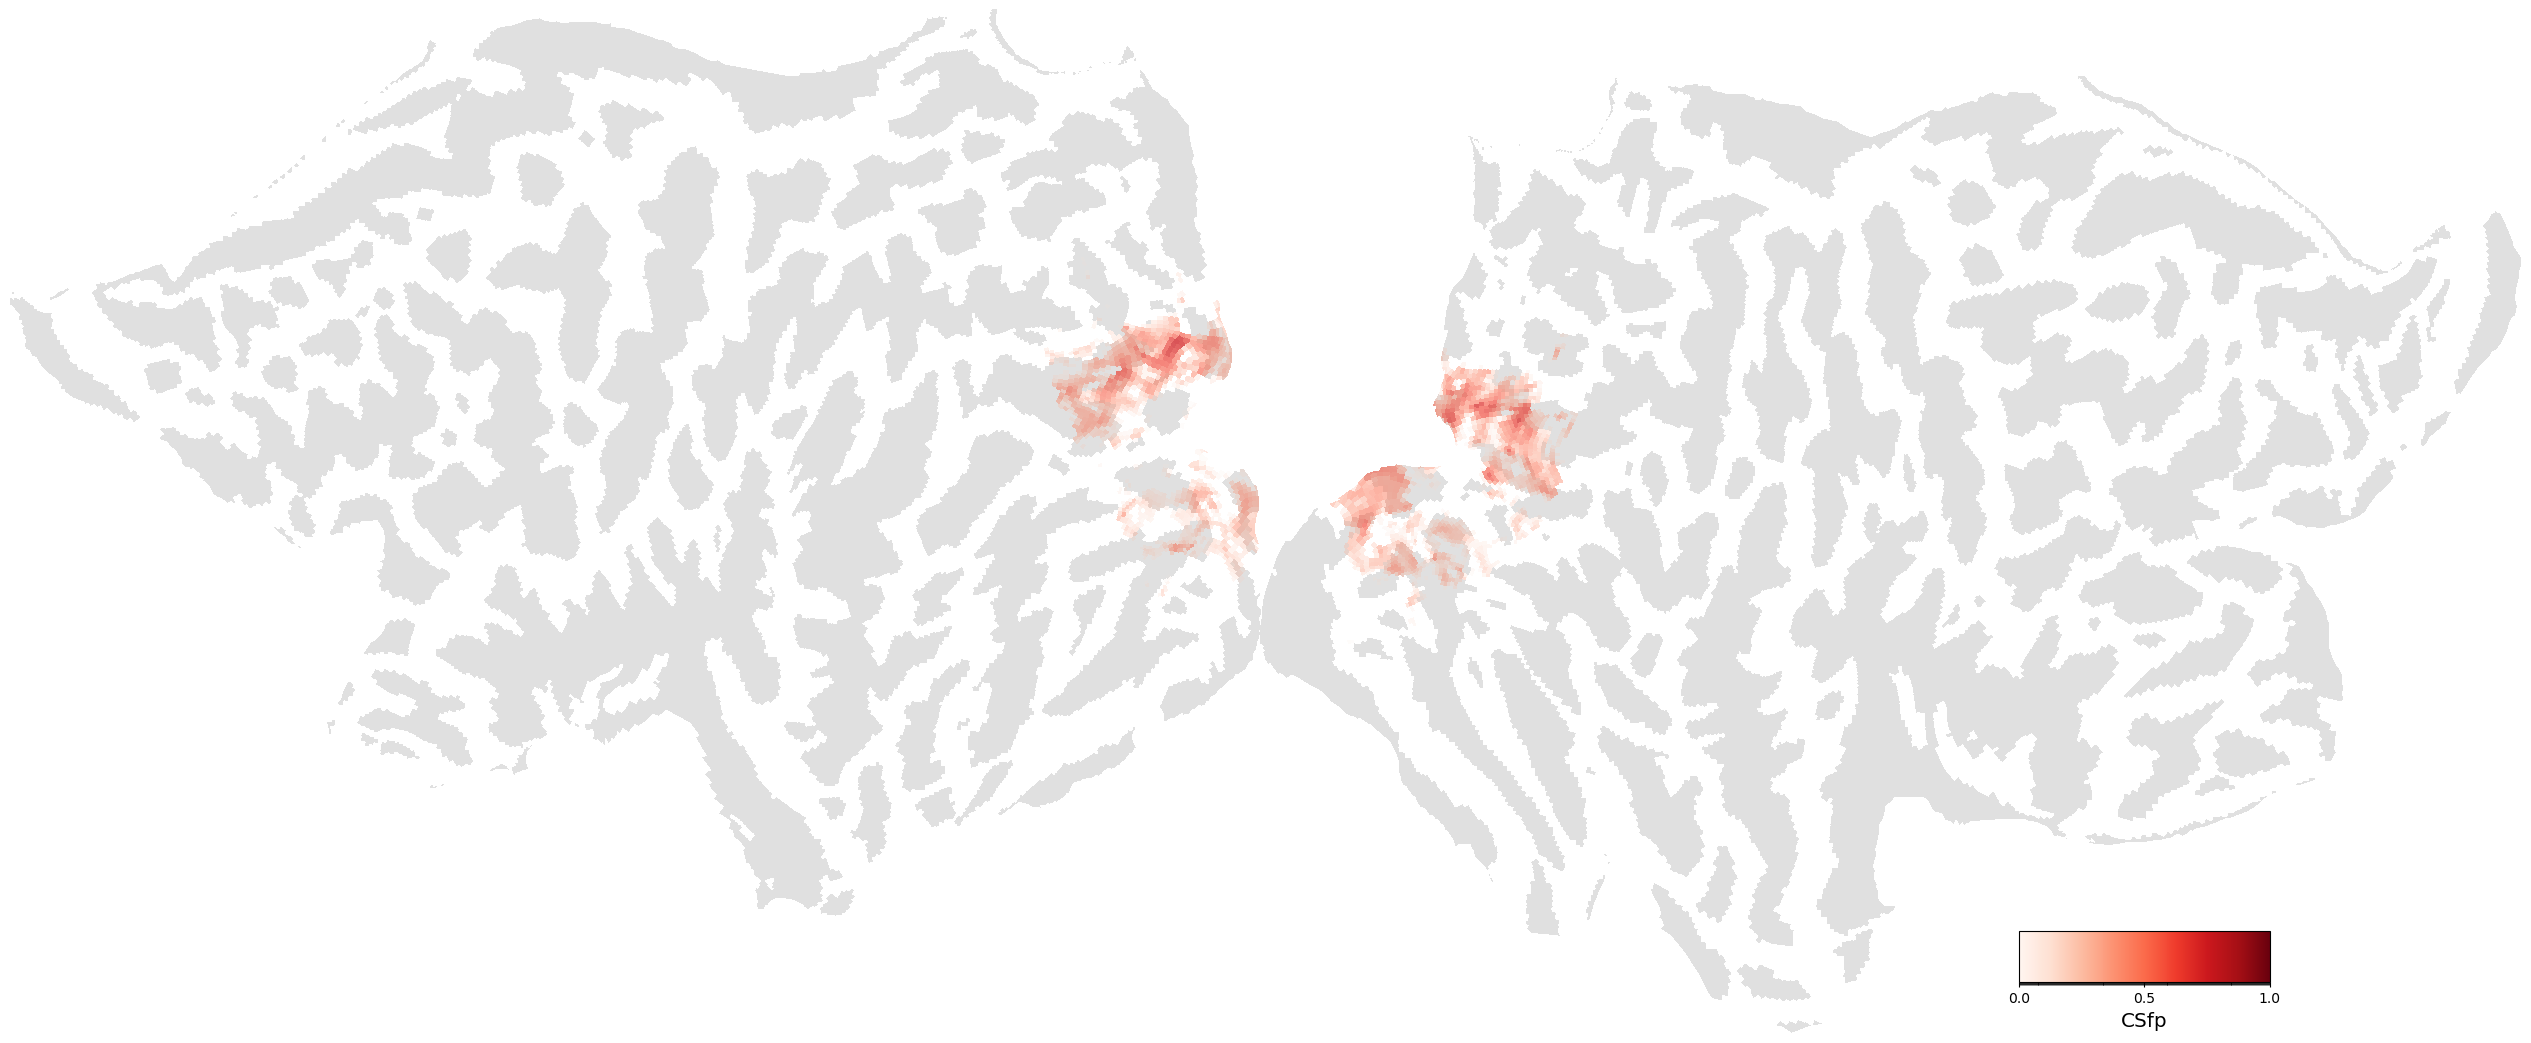

In [27]:
prf_loo_r2_idx = -1
loo_rsq_data = ncsf_fit59k[prf_loo_r2_idx,:]
alpha = loo_rsq_data
alpha_range = [0,1]
alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
alpha[alpha>1]=1

# put alpha to 0 outside non interest roi 

r2_params = {
             'subject': pycortex_subject,
             'data': ncsf_fit59k[prf_loo_r2_idx,:], 
             'cmap': 'Reds', 
             'alpha': alpha, 
             'vmin': 0, 
             'vmax': 1, 
             'cbar': 'discrete', 
             'cortex_type': 'VertexRGB', 
             'description': 'CSS pRF CM',
             'curv_brightness': 1, 
             'curv_contrast': 0.25, 
             'add_roi': False, 
             'cbar_label': 'CSfp',
             'with_labels': True}
volume_r2 = draw_cortex(**r2_params)
# plt.savefig('/Users/uriel/Downloads/R2.pdf')

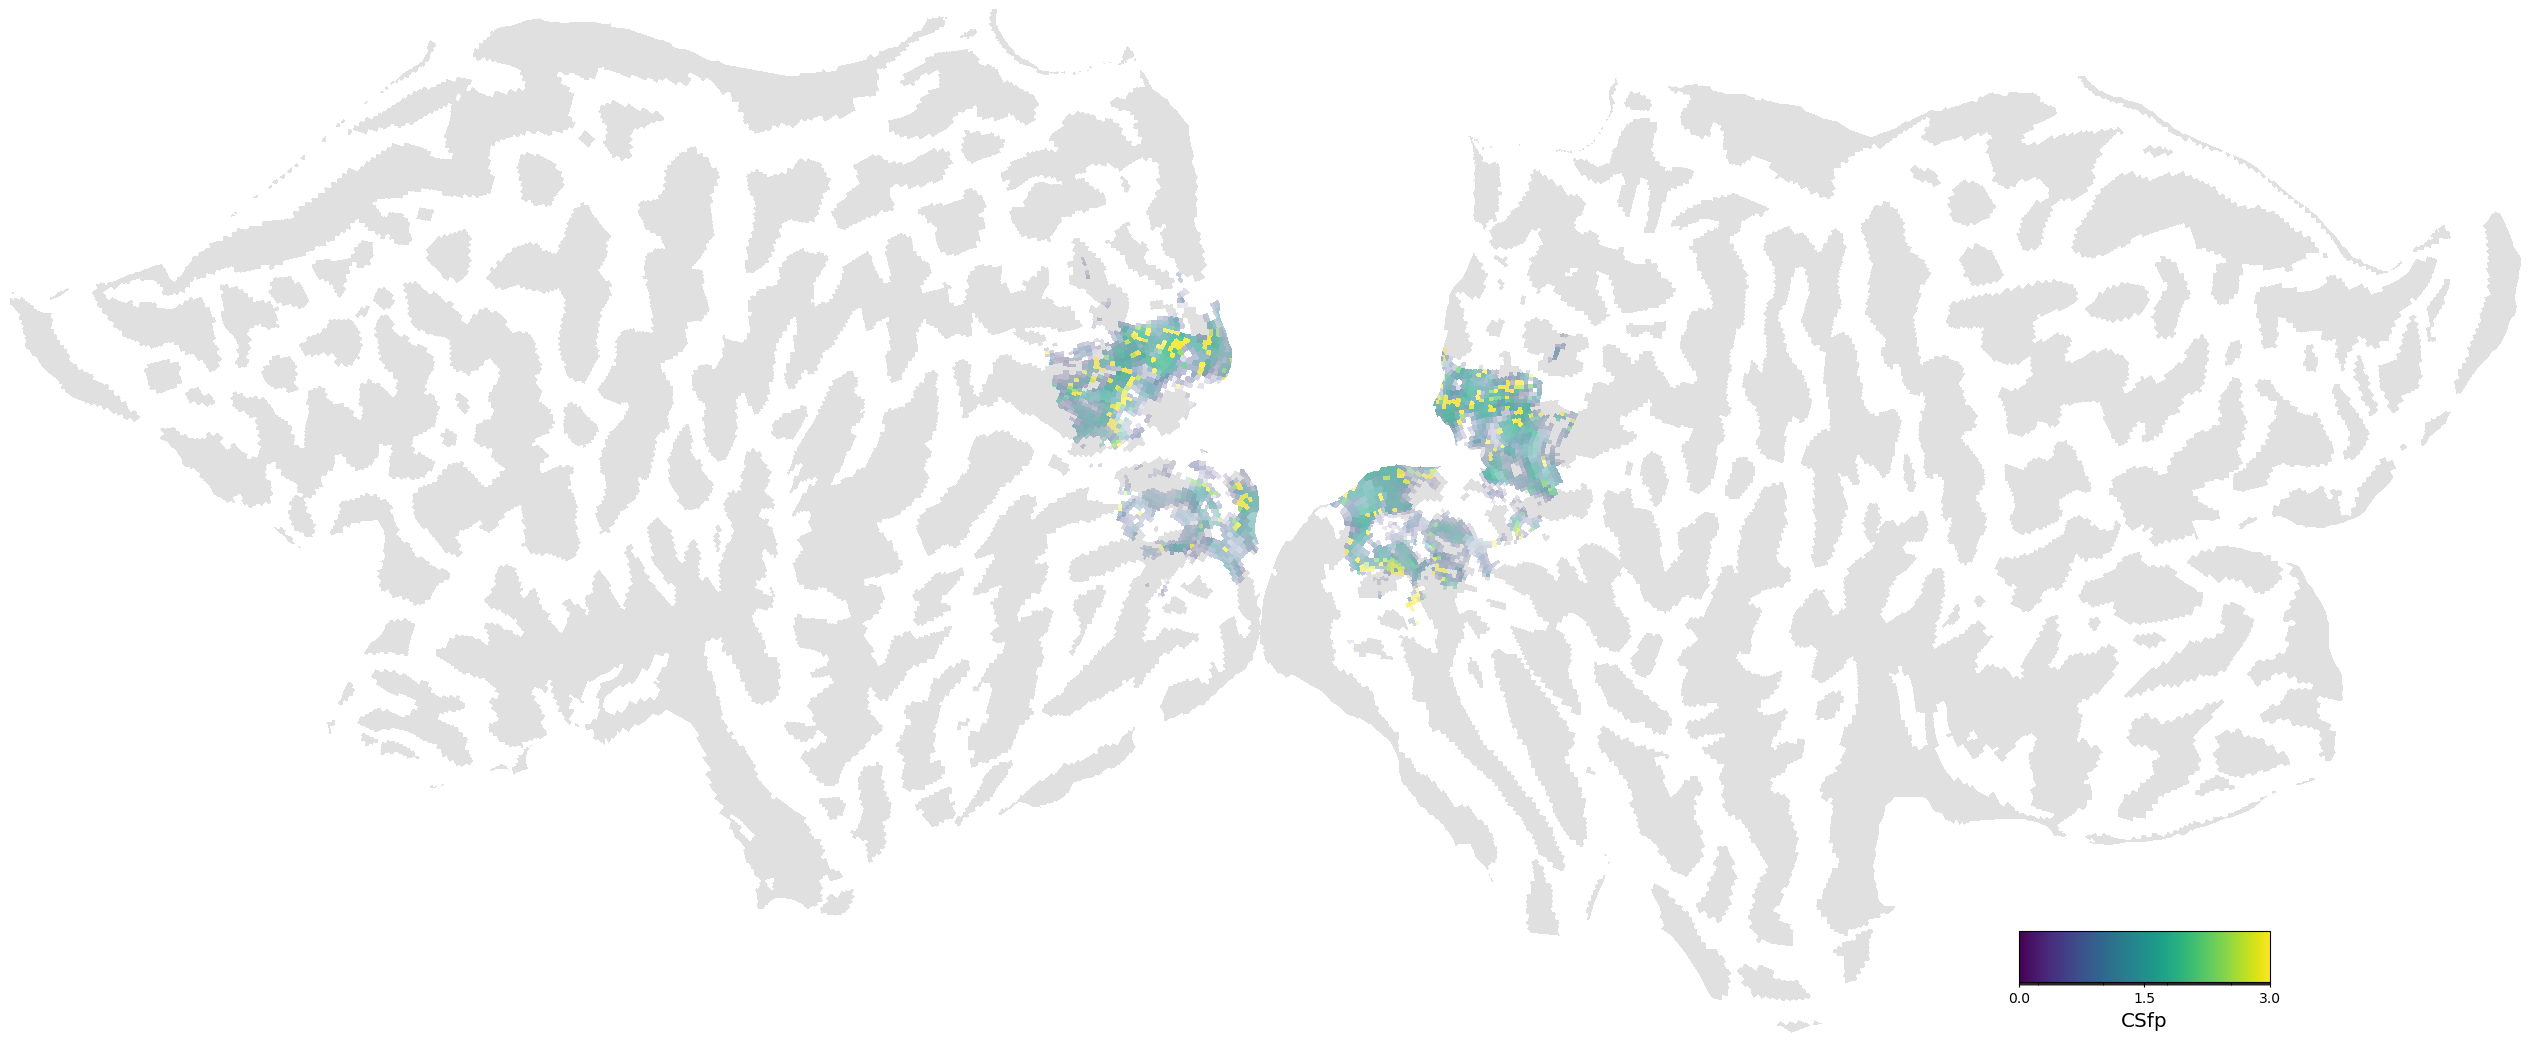

In [25]:
prf_loo_r2_idx = -1
loo_rsq_data = ncsf_fit59k[prf_loo_r2_idx,:]
alpha = loo_rsq_data
alpha_range = [0,1]
alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
alpha[alpha>1]=1

# put alpha to 0 outside non interest roi 

amp_params = {
             'subject': pycortex_subject,
             'data': ncsf_fit59k[5,:], 
             'cmap': 'viridis', 
             'alpha': alpha, 
             'vmin': 0, 
             'vmax': 3, 
             'cbar': 'discrete', 
             'cortex_type': 'VertexRGB', 
             'description': 'CSS pRF CM',
             'curv_brightness': 1, 
             'curv_contrast': 0.25, 
             'add_roi': False, 
             'cbar_label': 'CSfp',
             'with_labels': True}
volume_amp = draw_cortex(**amp_params)
# plt.savefig('/Users/uriel/Downloads/R2.pdf')

In [83]:
volume_sfp = draw_cortex(**sfp_params)
plt.savefig'')

SyntaxError: unmatched ')' (230101489.py, line 2)

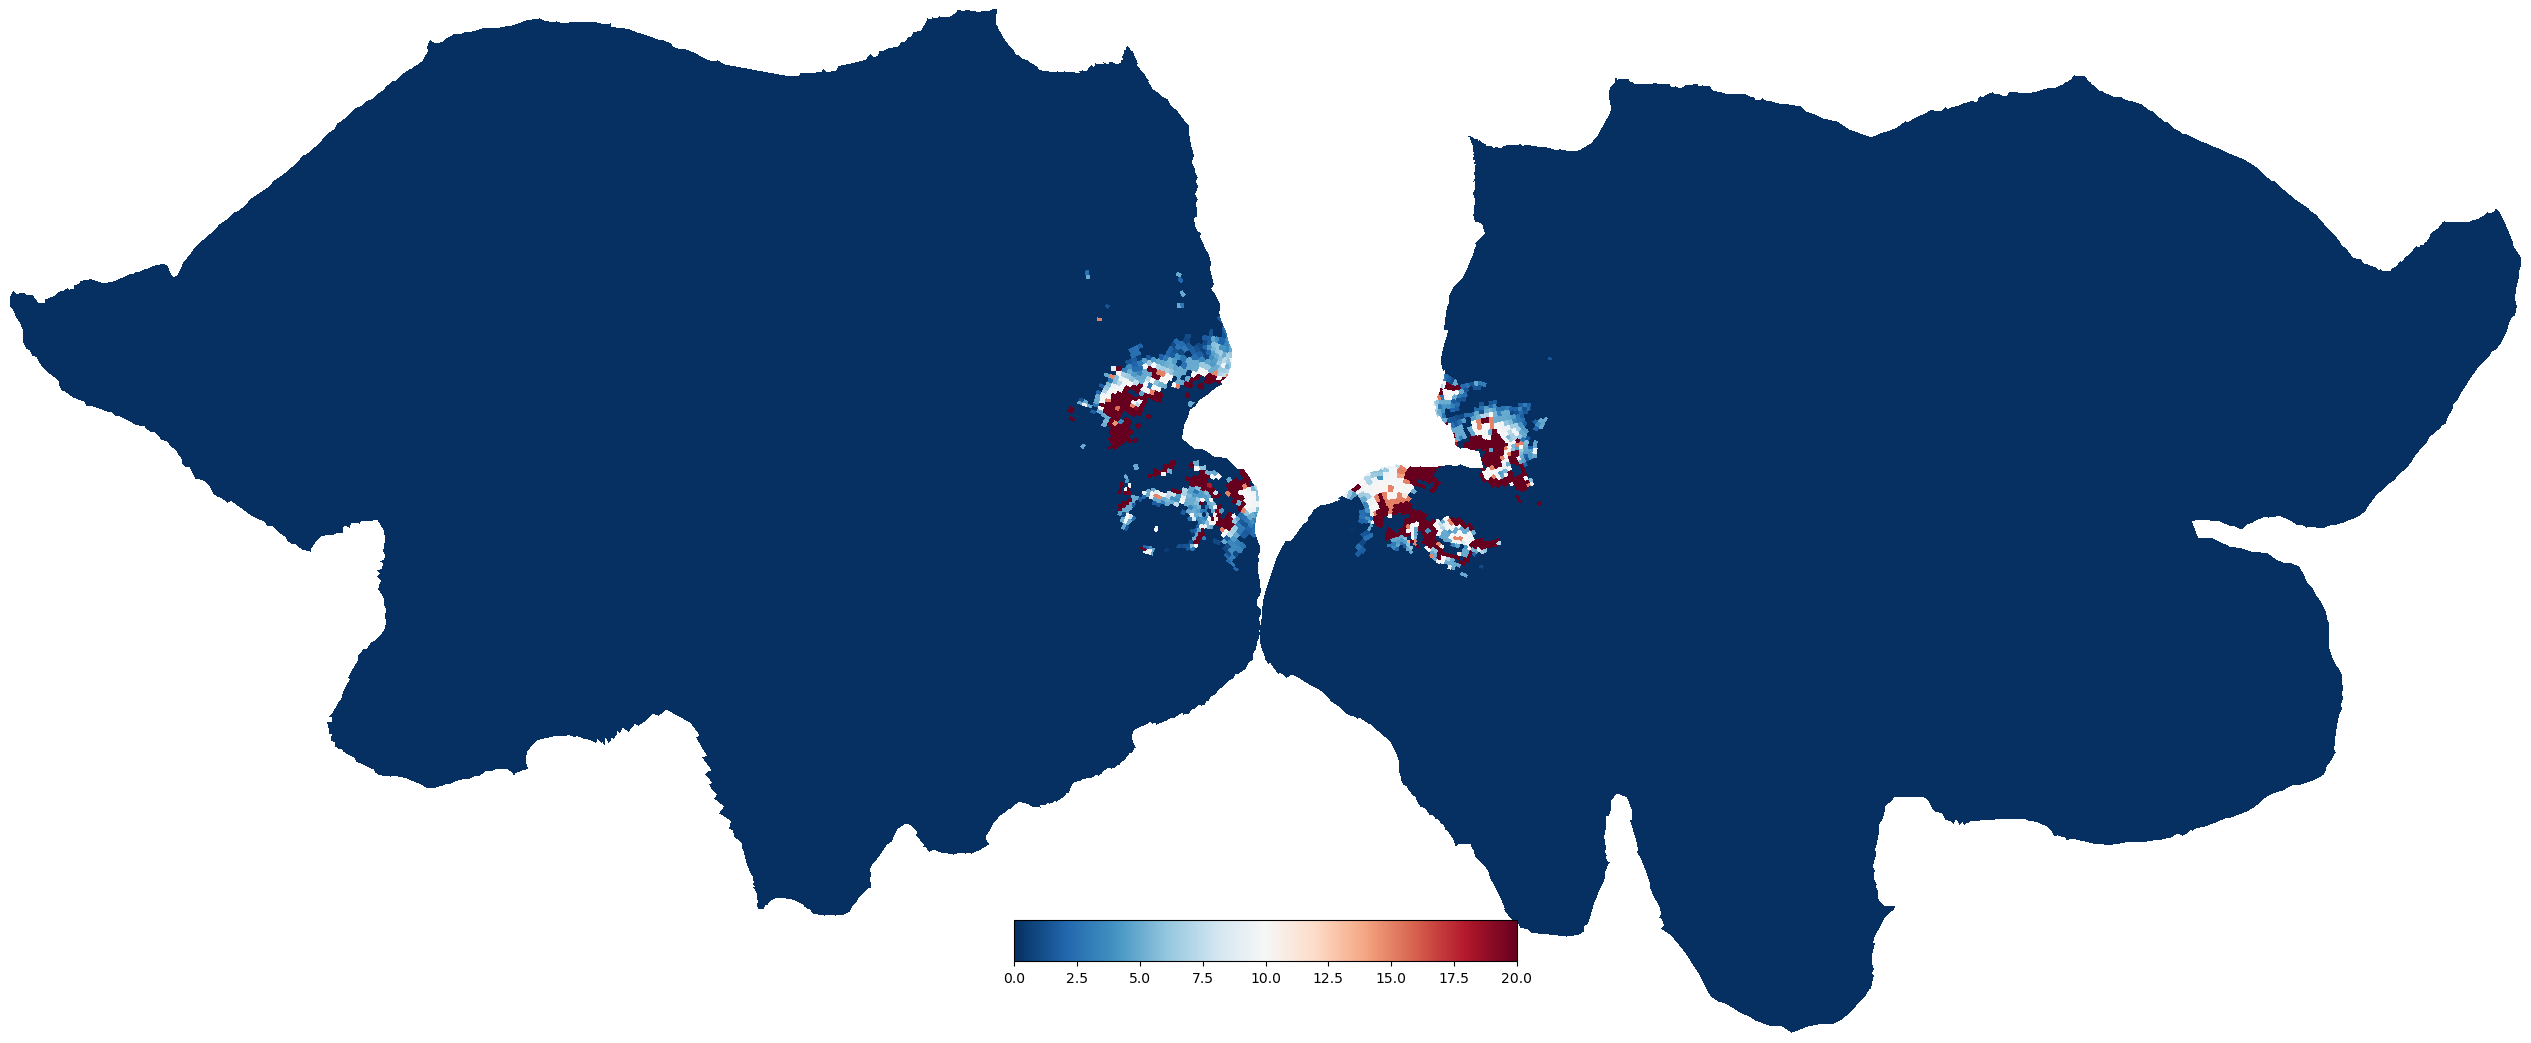

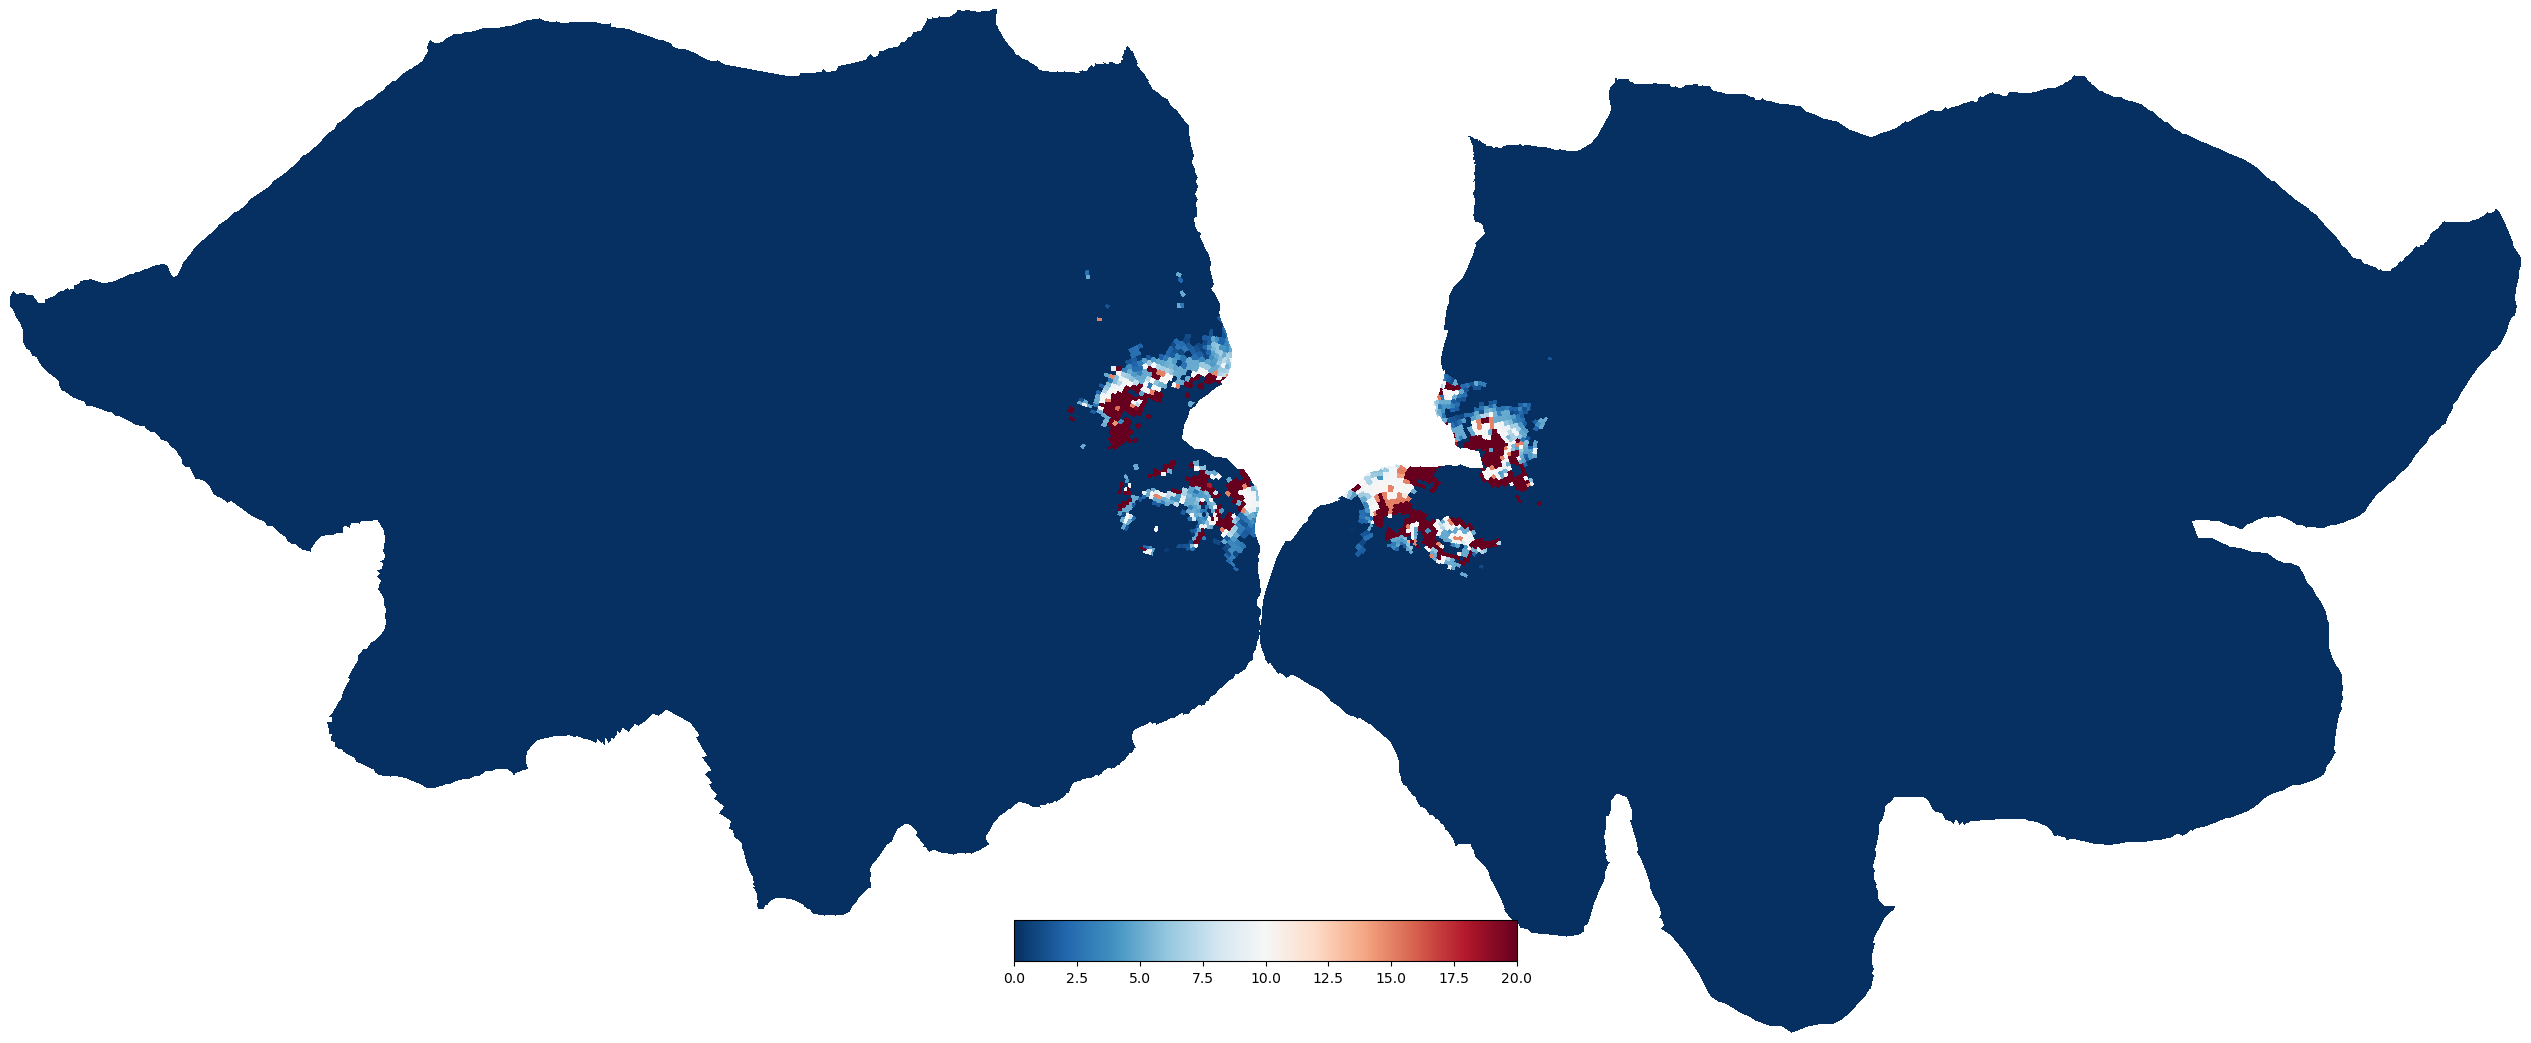

In [66]:
pycortex_subject = 'sub-hcp1.6mm'

data_59k =  from_170k_to_59k(img=img, data=ncsf_fit_mat.T, return_concat_hemis=True, return_59k_mask=False)
ncsf_fit59k = data_59k['data_concat']

vertex_data = cortex.Vertex(ncsf_fit59k[1,:], pycortex_subject, vmin=0, vmax=20)

cortex.quickshow(vertex_data, with_colorbar=True)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 118584))

In [ ]:
ncsf_fit_mat = np.where(ncsf_fit_mat == 0, np.nan, ncsf_fit_mat)
ncsf_pred_mat = np.where(ncsf_pred_mat == 0, np.nan, ncsf_pred_mat)

#export data from gauss model fit

# Define directories
if input_fn.endswith('.nii'):
    ncsf_fit_dir = "{}/{}/derivatives/pp_data/{}/170k/ncsf/fit".format(
        main_dir, project_dir, subject)
    os.makedirs(ncsf_fit_dir, exist_ok=True)

elif input_fn.endswith('.gii'):
    ncsf_fit_dir = "{}/{}/derivatives/pp_data/{}/fsnative/ncsf/fit".format(
        main_dir, project_dir, subject)
    os.makedirs(ncsf_fit_dir, exist_ok=True)

ncsf_fit_fn  = input_fn.split('/')[-1]
ncsf_fit_fn = ncsf_fit_fn.replace('bold', 'ncsf_fit')

ncsf_pred_fn = input_fn.split('/')[-1]
ncsf_pred_fn = ncsf_pred_fn.replace('bold', 'ncsf_pred')


# export fit
img_ncsf_fit_mat = make_surface_image(data=ncsf_fit_mat.T, source_img=img, maps_names=ncsf_maps_names)
nb.save(img_ncsf_fit_mat,'{}/{}'.format(ncsf_fit_dir, ncsf_fit_fn)) 

# export pred
img_ncsf_pred_mat = make_surface_image(data=ncsf_pred_mat, source_img=img)
nb.save(img_ncsf_pred_mat,'{}/{}'.format(ncsf_fit_dir, ncsf_pred_fn)) 

# Print duration
end_time = datetime.datetime.now()
print("\nStart time:\t{start_time}\nEnd time:\t{end_time}\nDuration:\t{dur}".format(
start_time=start_time, end_time=end_time, dur=end_time - start_time))